In [3]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

def load_data(train_path, test_path):
    train_df=pd.read_csv(train_path)
    test_df=pd.read_csv(test_path)

    print("Train shape:",train_df.shape)
    print("Test shape :",test_df.shape)
    print("Missing values in train:",train_df.isna().sum().sum())
    print("Missing values in test :",test_df.isna().sum().sum())

    X_train=train_df.drop("Class",axis=1)
    y_train=train_df["Class"]
    X_test=test_df.drop("ID",axis=1)
    test_ids=test_df["ID"]

    return X_train,y_train,X_test,test_ids


print("Loading data")
train_path = r"C:\Users\komal\Documents\alrIEEEna_26_dataset\MLChallengeDataset\TRAIN.csv"
test_path = r"C:\Users\komal\Documents\alrIEEEna_26_dataset\MLChallengeDataset\TEST.csv"
X_train_raw, y_train, X_test_raw, test_ids = load_data(train_path, test_path)

Loading data
Train shape: (43776, 48)
Test shape : (10944, 48)
Missing values in train: 0
Missing values in test : 0


In [4]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

def handle_outliers(X_train, X_test):
    print("Checking outliers")
    train_cap = X_train.copy()
    test_cap = X_test.copy()
    total_outliers = 0
    feature_cols = [c for c in X_train.columns if c.startswith("F")]

    for col in feature_cols:
        q1 = X_train[col].quantile(0.25)
        q3 = X_train[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
        total_outliers += outliers
        low_cap = X_train[col].quantile(0.01)
        high_cap = X_train[col].quantile(0.99)
        train_cap[col] = np.clip(X_train[col], low_cap, high_cap)
        test_cap[col] = np.clip(X_test[col], low_cap, high_cap)

    print("Total outliers detected:", total_outliers)
    return train_cap, test_cap

X_train_capped, X_test_capped = handle_outliers(X_train_raw, X_test_raw)

Checking outliers
Total outliers detected: 272392


In [5]:
def feature_engineering(df):
    df_copy = df.copy()
    sensor_cols = [c for c in df_copy.columns if c.startswith("F")]
    new_features = {}

    new_features["sensor_mean"] = df_copy[sensor_cols].mean(axis=1)
    new_features["sensor_std"] = df_copy[sensor_cols].std(axis=1)
    new_features["sensor_skew"] = df_copy[sensor_cols].skew(axis=1)
    new_features["sensor_kurt"] = df_copy[sensor_cols].kurtosis(axis=1)

    new_features["sensor_min"] = df_copy[sensor_cols].min(axis=1)
    new_features["sensor_max"] = df_copy[sensor_cols].max(axis=1)

    new_features["sensor_median"] = df_copy[sensor_cols].median(axis=1)
    new_features["sensor_q25"] = df_copy[sensor_cols].quantile(0.25, axis=1)
    new_features["sensor_q75"] = df_copy[sensor_cols].quantile(0.75, axis=1)

    for i in range(1, len(sensor_cols)):
        prev_col = sensor_cols[i - 1]
        curr_col = sensor_cols[i]
        roc_name = f"roc_{prev_col}_{curr_col}"
        new_features[roc_name] = df_copy[curr_col] - df_copy[prev_col]

    for col in sensor_cols:
        dev_name = f"dev_{col}"
        new_features[dev_name] = df_copy[col] - new_features["sensor_mean"]

    new_df = pd.DataFrame(new_features)
    result = pd.concat([df_copy, new_df], axis=1)
    return result

X_train_eng = feature_engineering(X_train_capped)
X_test_eng = feature_engineering(X_test_capped)
print("complete")

complete


In [6]:
def feature_selection(X_train, y_train, X_test, drop_bottom_pct=0.20):
    print("Feature selection")

    model = LGBMClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    keep_count = int(len(X_train.columns) * (1 - drop_bottom_pct))
    top_features = importance_df.head(keep_count)["feature"].tolist()

    print("Keeping features:",keep_count)
    print("Dropped features:",len(X_train.columns) - keep_count)
    return X_train[top_features].copy(), X_test[top_features].copy()

X_train_clean, X_test_clean = feature_selection(
    X_train_eng,
    y_train,
    X_test_eng,
    drop_bottom_pct=0.15
)

Feature selection
Keeping features: 126
Dropped features: 23


In [7]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [8]:
def try_models(X_train, y_train):
    models = {
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "GradientBoost": GradientBoostingClassifier(random_state=42),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
        "DecisionTree": DecisionTreeClassifier(random_state=42),
        "LogisticRegression": LogisticRegression(max_iter=500, random_state=42),
        "NaiveBayes": GaussianNB(),
        "XGBoost": XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "CatBoost": CatBoostClassifier(
            verbose=0,
            random_state=42,
            thread_count=-1
        ),
        "LightGBM": LGBMClassifier(
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        "HistGradientBoost": HistGradientBoostingClassifier(random_state=42)
    }
    scores = {}
    for name, model in models.items():
        try:
            cv_scores = cross_val_score(
                model,
                X_train,
                y_train,
                cv=3,
                scoring="f1_macro",
                n_jobs=-1
            )
            mean_score = cv_scores.mean()
            scores[name] = mean_score
            print(f"{name}(F1_macro): {mean_score:.4f}")
        except Exception as e:
            print(f"{name} failed:", e)

    sorted_models= sorted(scores.items(), key=lambda x: x[1], reverse=True)
    print("\nTop models:")
    for name,score in sorted_models[:4]:
        print(f"{name}: {score:.4f}")

print("\nModel comparison")
try_models(X_train_clean, y_train)


Model comparison
AdaBoost(F1_macro): 0.7183
GradientBoost(F1_macro): 0.8734
RandomForest(F1_macro): 0.9780
DecisionTree(F1_macro): 0.9358
LogisticRegression(F1_macro): 0.7020
NaiveBayes(F1_macro): 0.6569
XGBoost(F1_macro): 0.9832
CatBoost(F1_macro): 0.9843
LightGBM(F1_macro): 0.9749
HistGradientBoost(F1_macro): 0.9751

Top models:
CatBoost: 0.9843
XGBoost: 0.9832
RandomForest: 0.9780
HistGradientBoost: 0.9751


In [25]:
import optuna
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score

In [10]:
def scale_fold_features(X_tr,X_val,X_te):
    scaler=RobustScaler()
    scaler.fit(X_tr)

    X_tr=scaler.transform(X_tr)
    X_val=scaler.transform(X_val)
    X_te=scaler.transform(X_te)

    X_tr=pd.DataFrame(X_tr,columns=X_tr_cols)
    X_val=pd.DataFrame(X_val,columns=X_val_cols)
    X_te=pd.DataFrame(X_te,columns=X_te_cols)

    return X_tr,X_val,X_te

def optimize_models(X_train,y_train,n_trials=30):
    best_params={}
    models=["HistGradientBoosting","XGBoost","CatBoost","RandomForest"]

    for model_name in models:
        print(f"Tuning {model_name}")
        def objective(trial):
            if model_name=="HistGradientBoosting":
                params={
                    "learning_rate":trial.suggest_float("learning_rate",0.01,0.1,log=True),
                    "max_iter":trial.suggest_int("max_iter",200,500),
                    "max_depth":trial.suggest_int("max_depth",3,7),
                    "l2_regularization":trial.suggest_float("l2_regularization",0.1,5.0,log=True),
                    "class_weight":"balanced",
                    "random_state":42
                }
                model=HistGradientBoostingClassifier(**params)
            elif model_name=="XGBoost":
                pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
                params={
                    "n_estimators":trial.suggest_int("n_estimators",200,500),
                    "learning_rate":trial.suggest_float("learning_rate",0.01,0.1,log=True),
                    "max_depth":trial.suggest_int("max_depth",3,7),
                    "scale_pos_weight":pos_weight,
                    "eval_metric":"logloss",
                    "random_state":42,
                    "n_jobs":-1
                }
                model=XGBClassifier(**params)
            elif model_name=="CatBoost":
                params={
                    "iterations":trial.suggest_int("iterations",200,500),
                    "depth":trial.suggest_int("depth",3,7),
                    "auto_class_weights":"Balanced",
                    "random_state":42,
                    "verbose":0,
                    "thread_count":-1
                }
                model=CatBoostClassifier(**params)
            else:
                params={
                    "n_estimators":trial.suggest_int("n_estimators",200,500),
                    "max_depth":trial.suggest_int("max_depth",5,10),
                    "class_weight":"balanced",
                    "random_state":42,
                    "n_jobs":-1
                }
                model=RandomForestClassifier(**params)

            skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
            oof_preds=np.zeros(len(X_train))

            for train_idx,val_idx in skf.split(X_train,y_train):
                X_tr=X_train.iloc[train_idx]
                X_val=X_train.iloc[val_idx]
                y_tr=y_train.iloc[train_idx]
                scaler=RobustScaler()
                scaler.fit(X_tr)
                X_tr_scaled=scaler.transform(X_tr)
                X_val_scaled=scaler.transform(X_val)
                model.fit(X_tr_scaled,y_tr)
                oof_preds[val_idx]=model.predict_proba(X_val_scaled)[:,1]
            best_f1=max(
                f1_score(
                    y_train,
                    (oof_preds>=t).astype(int),
                    average="macro"
                )
                for t in np.arange(0.3,0.7,0.1)
            )
            return best_f1

        study=optuna.create_study(direction="maximize")
        study.optimize(objective,n_trials=n_trials)

        best_params[model_name]=study.best_params
        print(f"Best {model_name} F1: {study.best_value:.4f}")

    print("\nOptimization finished")
    return best_params


tuned_params=optimize_models(X_train_clean,y_train,n_trials=30)

[I 2026-03-07 08:08:15,945] A new study created in memory with name: no-name-c97d9237-ce58-4706-9ce5-ab74f879100f


Tuning HistGradientBoosting


[I 2026-03-07 08:08:33,068] Trial 0 finished with value: 0.8885180478116723 and parameters: {'learning_rate': 0.03094293206891217, 'max_iter': 356, 'max_depth': 3, 'l2_regularization': 0.24744534407209973}. Best is trial 0 with value: 0.8885180478116723.
[I 2026-03-07 08:08:48,079] Trial 1 finished with value: 0.9201347425495408 and parameters: {'learning_rate': 0.034923673086657475, 'max_iter': 485, 'max_depth': 3, 'l2_regularization': 0.9717997099548299}. Best is trial 1 with value: 0.9201347425495408.
[I 2026-03-07 08:09:02,021] Trial 2 finished with value: 0.8652107578093429 and parameters: {'learning_rate': 0.018230861211797466, 'max_iter': 425, 'max_depth': 3, 'l2_regularization': 0.29897049641714757}. Best is trial 1 with value: 0.9201347425495408.
[I 2026-03-07 08:09:17,090] Trial 3 finished with value: 0.9652527852863518 and parameters: {'learning_rate': 0.0616051969988122, 'max_iter': 353, 'max_depth': 4, 'l2_regularization': 1.957440026694626}. Best is trial 3 with value: 0.

Best HistGradientBoosting F1: 0.9843
Tuning XGBoost


[I 2026-03-07 08:17:58,181] Trial 0 finished with value: 0.9716656195066433 and parameters: {'n_estimators': 262, 'learning_rate': 0.027887376697912622, 'max_depth': 7}. Best is trial 0 with value: 0.9716656195066433.
[I 2026-03-07 08:18:10,935] Trial 1 finished with value: 0.9485396318765229 and parameters: {'n_estimators': 439, 'learning_rate': 0.06169581897413521, 'max_depth': 3}. Best is trial 0 with value: 0.9716656195066433.
[I 2026-03-07 08:18:46,798] Trial 2 finished with value: 0.9647607778753198 and parameters: {'n_estimators': 437, 'learning_rate': 0.017962362707648206, 'max_depth': 6}. Best is trial 0 with value: 0.9716656195066433.
[I 2026-03-07 08:19:31,781] Trial 3 finished with value: 0.9841433466585473 and parameters: {'n_estimators': 397, 'learning_rate': 0.041406050389642485, 'max_depth': 7}. Best is trial 3 with value: 0.9841433466585473.
[I 2026-03-07 08:19:41,274] Trial 4 finished with value: 0.9213336668615069 and parameters: {'n_estimators': 305, 'learning_rate'

Best XGBoost F1: 0.9880
Tuning CatBoost


[I 2026-03-07 08:34:57,692] Trial 0 finished with value: 0.983819275206524 and parameters: {'iterations': 208, 'depth': 7}. Best is trial 0 with value: 0.983819275206524.
[I 2026-03-07 08:35:50,625] Trial 1 finished with value: 0.9830323350633745 and parameters: {'iterations': 374, 'depth': 6}. Best is trial 0 with value: 0.983819275206524.
[I 2026-03-07 08:36:37,906] Trial 2 finished with value: 0.9830718839685196 and parameters: {'iterations': 335, 'depth': 6}. Best is trial 0 with value: 0.983819275206524.
[I 2026-03-07 08:37:14,565] Trial 3 finished with value: 0.9793980589987208 and parameters: {'iterations': 360, 'depth': 5}. Best is trial 0 with value: 0.983819275206524.
[I 2026-03-07 08:38:31,846] Trial 4 finished with value: 0.9857567782397061 and parameters: {'iterations': 350, 'depth': 7}. Best is trial 4 with value: 0.9857567782397061.
[I 2026-03-07 08:38:52,070] Trial 5 finished with value: 0.9541232067181193 and parameters: {'iterations': 306, 'depth': 3}. Best is trial 4

Best CatBoost F1: 0.9865
Tuning RandomForest


[I 2026-03-07 09:05:39,277] Trial 0 finished with value: 0.8957062746957261 and parameters: {'n_estimators': 226, 'max_depth': 8}. Best is trial 0 with value: 0.8957062746957261.
[I 2026-03-07 09:07:02,157] Trial 1 finished with value: 0.9194711014792711 and parameters: {'n_estimators': 384, 'max_depth': 9}. Best is trial 1 with value: 0.9194711014792711.
[I 2026-03-07 09:07:29,251] Trial 2 finished with value: 0.820660820187475 and parameters: {'n_estimators': 209, 'max_depth': 5}. Best is trial 1 with value: 0.9194711014792711.
[I 2026-03-07 09:08:28,185] Trial 3 finished with value: 0.8959511694197084 and parameters: {'n_estimators': 320, 'max_depth': 8}. Best is trial 1 with value: 0.9194711014792711.
[I 2026-03-07 09:09:53,298] Trial 4 finished with value: 0.8962569855617468 and parameters: {'n_estimators': 462, 'max_depth': 8}. Best is trial 1 with value: 0.9194711014792711.
[I 2026-03-07 09:10:26,158] Trial 5 finished with value: 0.8213771389952473 and parameters: {'n_estimators

Best RandomForest F1: 0.9398

Optimization finished


In [18]:
from sklearn.ensemble import StackingClassifier

In [21]:
def stacked_model(y_train,tuned_params):
    pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])

    xgb=XGBClassifier(**tuned_params['XGBoost'],eval_metric='logloss',scale_pos_weight=pos_weight,random_state=42,n_jobs=2)
    hgb=HistGradientBoostingClassifier(**tuned_params['HistGradientBoosting'],class_weight='balanced',random_state=42)
    cat=CatBoostClassifier(**tuned_params['CatBoost'],auto_class_weights='Balanced',verbose=0,random_state=42,thread_count=2)
    rf=RandomForestClassifier(**tuned_params['RandomForest'],class_weight='balanced',random_state=42,n_jobs=2)

    
    estimators=[('xgb',xgb),('hgb',hgb),('cat',cat),('rf',rf)]
    meta_clf=LogisticRegression(class_weight='balanced',C=0.1,max_iter=1000)
    return StackingClassifier(estimators=estimators,final_estimator=meta_clf,cv=5,n_jobs=-1)

print("\n5-Fold CV training")
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

oof_probs=np.zeros(len(X_train_clean))
test_probs_averaged=np.zeros(len(X_test_clean))

last_model,last_X_val=None,None
for fold,(train_idx,val_idx) in enumerate(skf.split(X_train_clean,y_train)):
    print(f"Training fold {fold+1}/5")
    X_tr=X_train_clean.iloc[train_idx]
    y_tr=y_train.iloc[train_idx]
    X_va=X_train_clean.iloc[val_idx]
    y_va=y_train.iloc[val_idx]

    X_tr_scaled,X_va_scaled,X_test_scaled_fold=scale_fold_features(X_tr,X_va,X_test_clean)

    model=stacked_model(y_tr,tuned_params)
    model.fit(X_tr_scaled,y_tr)
    oof_probs[val_idx]=model.predict_proba(X_va_scaled)[:,1]
    test_probs_averaged+=model.predict_proba(X_test_scaled_fold)[:,1]/skf.n_splits
    if fold==4:
        last_model,last_X_val=model,X_va_scaled


5-Fold CV training
Training fold 1/5
Training fold 2/5
Training fold 3/5
Training fold 4/5
Training fold 5/5



Optimizing threshold & SHAP analysis

Optimal Macro F1-score: 0.9883
Accuracy: 0.9888
Achieved at Threshold: 0.57

Confusion Matrix
[26277  188]
[303  17008]

Confusion matrix components
True Negatives:26277
False Positives:188
False Negatives:303
True Positives:17008

Generating SHAP explanations using LightGBM base estimator
Saved SHAP visualization to 'shap_summary.png'


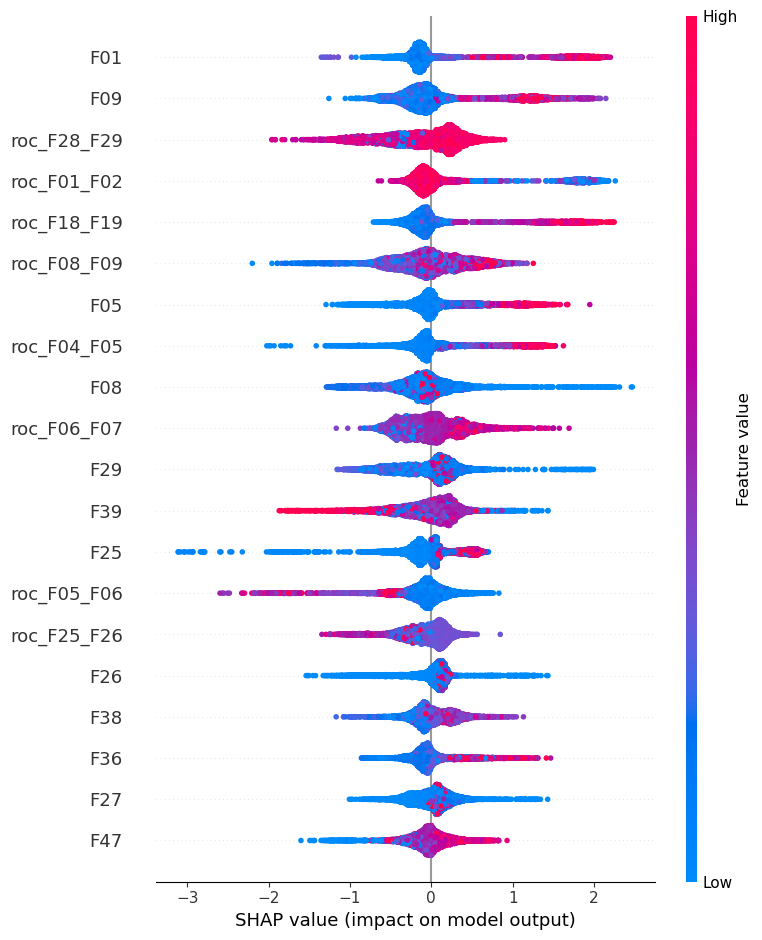

In [26]:
import shap as shp
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

def optimize_threshold(y_true,y_probs):
    best_thresh=0.5
    best_f1=0.0
    th_vals=np.arange(0.1,0.9,0.01)
    for t in th_vals:
        preds=(y_probs>=t).astype(int)
        sc=f1_score(y_true,preds,average='macro')
        if sc>best_f1:
            best_f1=sc
            best_thresh=t

    final_preds=(y_probs>=best_thresh).astype(int)
    acc=accuracy_score(y_true,final_preds)
    print(f"\nOptimal Macro F1-score: {best_f1:.4f}\nAccuracy: {acc:.4f}\nAchieved at Threshold: {best_thresh:.2f}")
    cm=confusion_matrix(y_true,final_preds)
    tn,fp,fn,tp=cm.ravel()
    print("\nConfusion Matrix")
    print(f"[{tn}  {fp}]")
    print(f"[{fn}  {tp}]")

    print("\nConfusion matrix components")
    print(f"True Negatives:{tn}")
    print(f"False Positives:{fp}")
    print(f"False Negatives:{fn}")
    print(f"True Positives:{tp}")
    return best_thresh

def my_shap(model,X_val):
    print("\nGenerating SHAP explanations using LightGBM base estimator")
    base_model=model.named_estimators_['xgb']
    explainer=shp.TreeExplainer(base_model)
    shap_vals=explainer.shap_values(X_val)
    if isinstance(shap_vals,list):
        vals=shap_vals[1]
    else:
        vals=shap_vals

    shp.summary_plot(vals,X_val,show=False)
    plt.tight_layout()
    plt.savefig("shap_summary.png",dpi=300)
    print("Saved SHAP visualization to 'shap_summary.png'")
print("\nOptimizing threshold & SHAP analysis")
best_thresh=optimize_threshold(y_train,oof_probs)
my_shap(last_model,last_X_val)
test_preds=(test_probs_averaged>=best_thresh).astype(int)
submission=pd.DataFrame({'ID':test_ids,'CLASS':test_preds})
save_path="C://Users//komal//Documents//alrIEEEna_26_dataset//MLChallengeDataset//FINAL.csv"
submission.to_csv(save_path,index=False)